In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

# Load processed monthly data
df = pd.read_csv("../data/monthly_data.csv")

# Convert ym column to datetime
df["ym"] = pd.to_datetime(df["ym"])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (2400, 8)

Columns: ['STATION', 'year', 'month', 'PRCP_sum', 'TMAX_mean', 'TMIN_mean', 'TMEAN', 'ym']

Data types:
STATION              object
year                  int64
month                 int64
PRCP_sum            float64
TMAX_mean           float64
TMIN_mean           float64
TMEAN               float64
ym           datetime64[ns]
dtype: object


In [ ]:
df.head()

,STATION,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym
0,USW00003017,1996,6,1.74,85.083333,53.291667,69.187500,1996-06-01
1,USW00003017,1996,7,1.01,87.967742,58.774194,73.370968,1996-07-01
2,USW00003017,1996,8,0.56,87.064516,56.129032,71.596774,1996-08-01
3,USW00003017,1996,9,2.34,74.600000,46.900000,60.750000,1996-09-01
4,USW00003017,1996,10,0.39,64.903226,36.774194,50.838710,1996-10-01


In [4]:
# Basic summary statistics for numeric columns
df.describe()


,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym
count,2400.000000,2400.000000,2400.000000,2393.000000,2393.000000,2393.000000,2400
mean,2010.202917,6.549583,2.654263,70.816142,52.269247,61.513240,2010-08-31 05:10:48.000000256
min,1996.000000,1.000000,0.000000,23.428571,5.678571,14.709677,1996-06-01 00:00:00
25%,2003.000000,4.000000,0.470000,58.516129,40.700000,49.166667,2003-07-01 00:00:00
50%,2010.000000,7.000000,1.710000,73.580645,53.466667,63.612903,2010-09-01 00:00:00
75%,2017.000000,10.000000,3.762500,83.166667,64.266667,73.866667,2017-11-01 00:00:00
max,2024.000000,12.000000,19.620000,114.677419,90.806452,103.064516,2024-12-01 00:00:00
std,8.256824,3.447462,2.975210,17.455531,16.900868,16.913594,NaN


In [5]:
# Count missing values in each column
df.isna().sum()

STATION      0
year         0
month        0
PRCP_sum     0
TMAX_mean    7
TMIN_mean    7
TMEAN        7
ym           0
dtype: int64

## Station coverage

In [5]:
station_counts = df['STATION'].value_counts()
print(f'Total stations: {station_counts.shape[0]}')
station_counts.head(10)

Total stations: 7


STATION
USW00012839    343
USW00023183    343
USW00024233    343
USW00093134    343
USW00094789    343
USW00094846    343
USW00003017    342
Name: count, dtype: int64

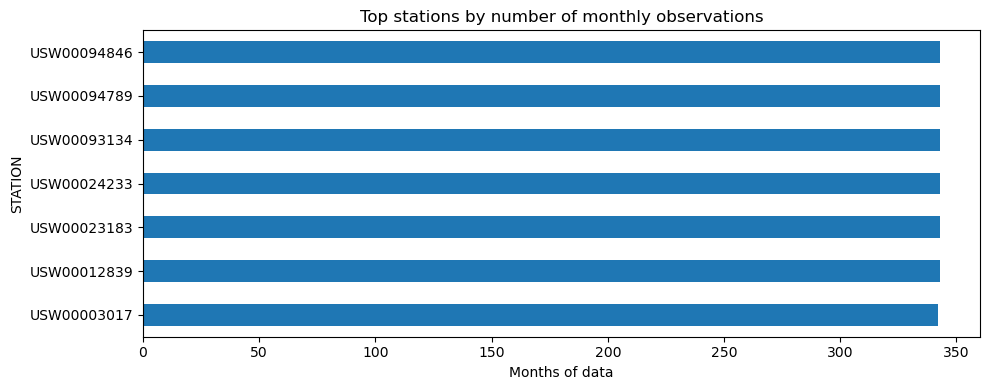

In [6]:
ax = station_counts.head(15).sort_values().plot(kind='barh', color='#1f77b4')
ax.set_title('Top stations by number of monthly observations')
ax.set_xlabel('Months of data')
plt.tight_layout()
plt.show()

## Station-level summary statistics

A station-wise table highlights how average precipitation and temperature differ across the representative locations.

In [14]:
station_summary = (
    df.groupby('STATION')[['PRCP_sum', 'TMEAN']]
      .agg(['mean', 'std'])
      .round(2)
)
station_summary.sort_values(('TMEAN', 'mean'), ascending=False).head(10)

PRCP_sum        TMEAN       
                mean   std   mean    std
STATION                                 
USW00012839     5.66  4.49  77.85   5.67
USW00023183     0.53  0.74  75.99  14.64
USW00093134     1.15  2.13  66.08   6.42
USW00094789     3.67  2.10  55.25  15.32
USW00024233     3.29  2.66  53.06   9.53
USW00003017     1.13  1.16  51.17  16.14
USW00094846     3.15  2.06  51.15  17.88

## Time trends

Tracking aggregate temperature and precipitation over time helps highlight slow-moving shifts or anomalous years across stations.

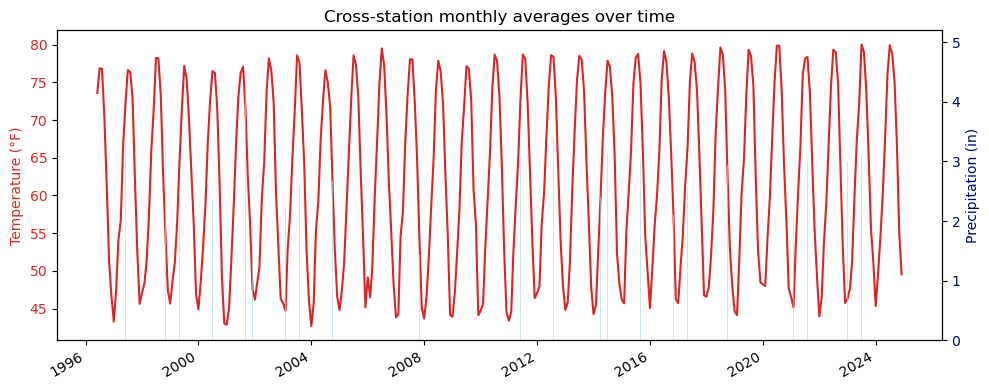

In [15]:
monthly_trends = (
    df.groupby('ym')[['PRCP_sum', 'TMEAN']].mean().sort_index()
)
fig, ax1 = plt.subplots()
ax1.plot(monthly_trends.index, monthly_trends['TMEAN'], color='#d62728', label='Avg monthly mean temp (°F)')
ax1.set_ylabel('Temperature (°F)', color='#d62728')
ax1.tick_params(axis='y', labelcolor='#d62728')
ax2 = ax1.twinx()
ax2.bar(monthly_trends.index, monthly_trends['PRCP_sum'], color='lightblue', alpha=0.6, label='Avg monthly precip (in)')
ax2.set_ylabel('Precipitation (in)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
ax1.set_title('Cross-station monthly averages over time')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Station-level temperature trajectories

Plotting each station separately reveals whether particular locations drive the long-term trends observed in the aggregate view.

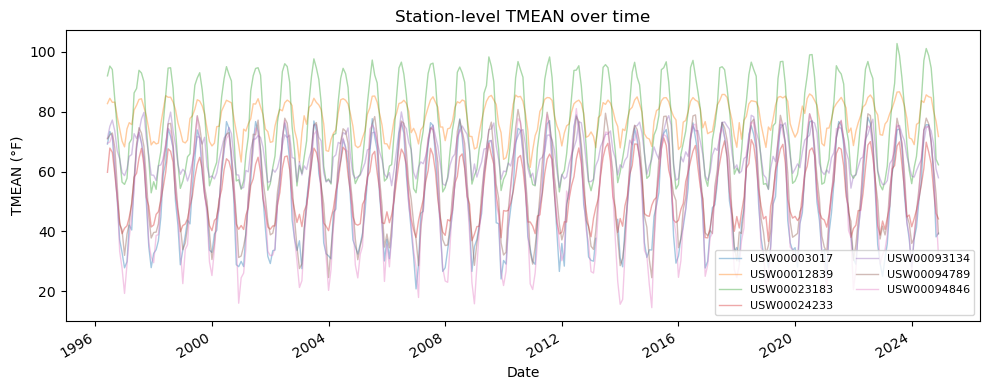

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for station, sub in df.groupby('STATION'):
    ax.plot(sub['ym'], sub['TMEAN'], linewidth=1, alpha=0.4, label=station)
ax.set_title('Station-level TMEAN over time')
ax.set_xlabel('Date')
ax.set_ylabel('TMEAN (°F)')
ax.legend(ncol=2, fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Seasonal patterns

Aggregating all years by calendar month reveals the typical seasonal signatures in precipitation and temperature.

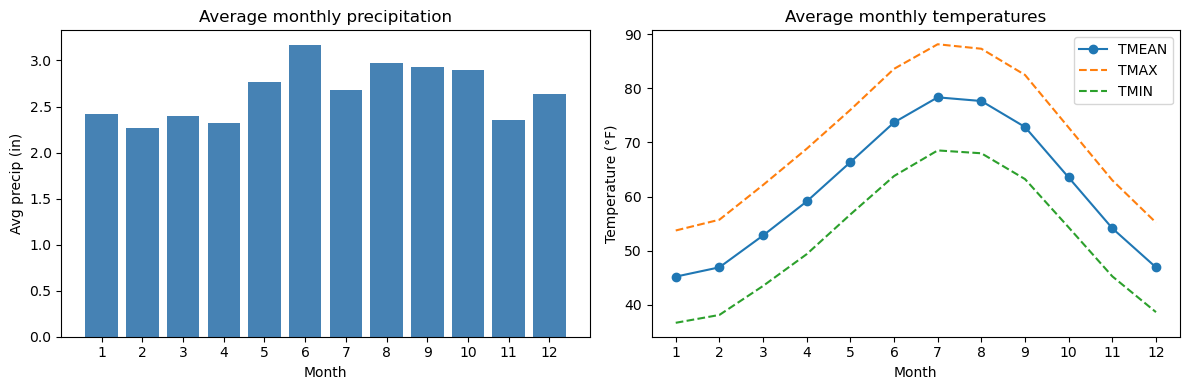

In [17]:
month_order = list(range(1, 13))
monthly_avg = (
    df.groupby('month')[['PRCP_sum', 'TMAX_mean', 'TMIN_mean', 'TMEAN']].mean()
    .reindex(month_order)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(month_order, monthly_avg['PRCP_sum'], color='steelblue')
axes[0].set_xticks(month_order)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg precip (in)')
axes[0].set_title('Average monthly precipitation')
axes[1].plot(month_order, monthly_avg['TMEAN'], marker='o', label='TMEAN')
axes[1].plot(month_order, monthly_avg['TMAX_mean'], linestyle='--', label='TMAX')
axes[1].plot(month_order, monthly_avg['TMIN_mean'], linestyle='--', label='TMIN')
axes[1].set_xticks(month_order)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Temperature (°F)')
axes[1].set_title('Average monthly temperatures')
axes[1].legend()
fig.tight_layout()
plt.show()

## Monthly temperature distributions

Box plots expose the spread and skew of temperature for each month.

/var/folders/x8/59lsc6h95bz9br5gwthbx0rw0000gn/T/ipykernel_48266/626944139.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxed, labels=month_order, showfliers=False)


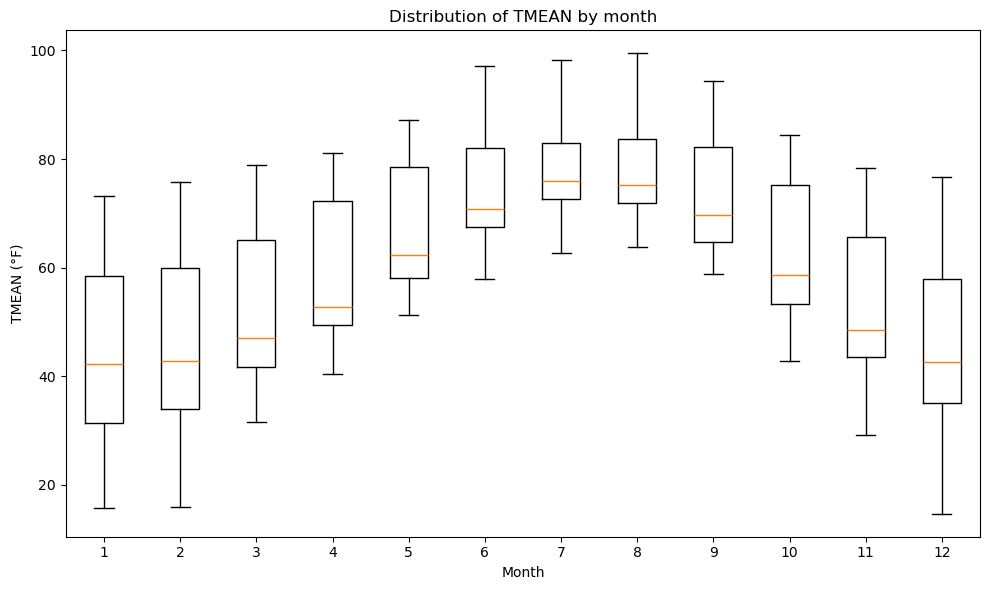

In [7]:
month_order = list(range(1, 13))
boxed = [df.loc[df['month'] == m, 'TMEAN'].dropna().values for m in month_order]
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(boxed, labels=month_order, showfliers=False)
ax.set_title('Distribution of TMEAN by month')
ax.set_xlabel('Month')
ax.set_ylabel('TMEAN (°F)')
plt.tight_layout()
plt.show()

## Value distributions

Histogram views of the core numeric fields make it easy to spot skew or potential outliers before modeling.

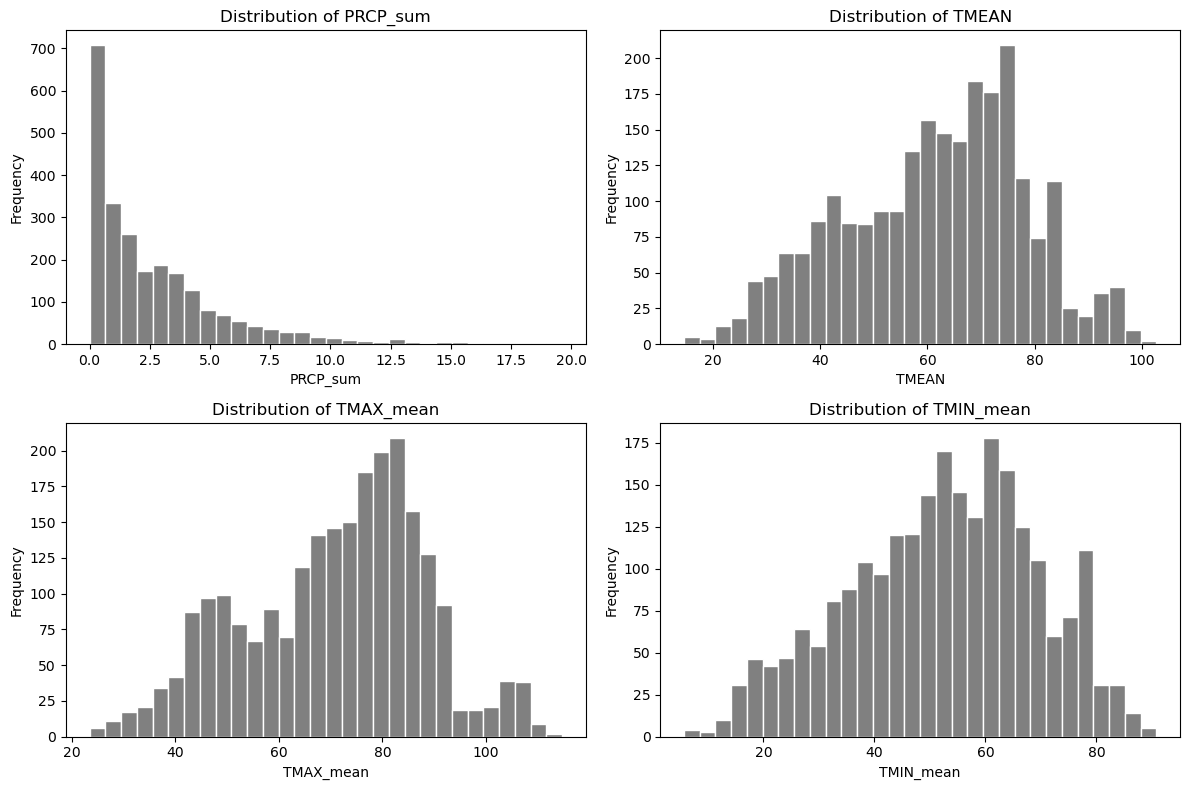

In [19]:
numeric_cols = ['PRCP_sum', 'TMEAN', 'TMAX_mean', 'TMIN_mean']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, color='gray', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
fig.tight_layout()
plt.show()

## Variable correlations

A correlation matrix summarizes the linear relationships among the monthly metrics to inform later feature selection.

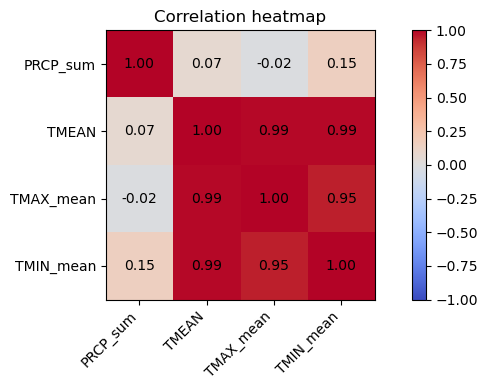

In [20]:
corr_cols = ['PRCP_sum', 'TMEAN', 'TMAX_mean', 'TMIN_mean']
corr = df[corr_cols].corr()
fig, ax = plt.subplots()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
ax.set_title('Correlation heatmap')
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Temperature versus precipitation

This scatter plot checks whether wetter months coincide with higher or lower temperatures at different stations.

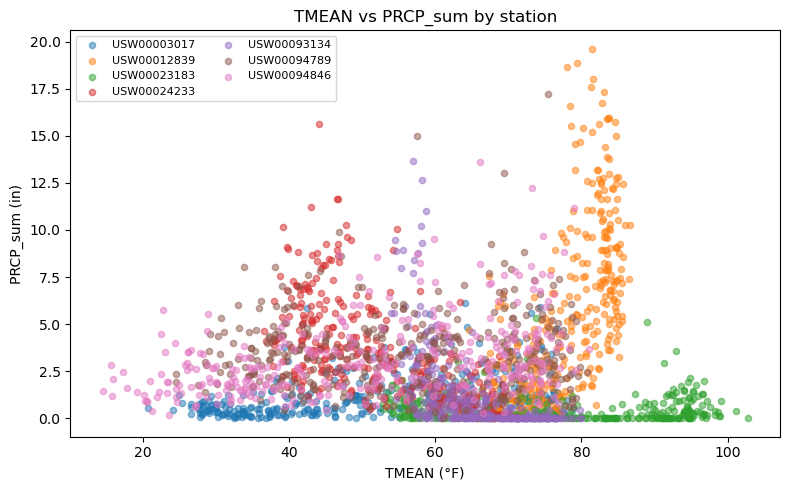

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
for station, sub in df.groupby('STATION'):
    ax.scatter(sub['TMEAN'], sub['PRCP_sum'], alpha=0.5, s=20, label=station)
ax.set_title('TMEAN vs PRCP_sum by station')
ax.set_xlabel('TMEAN (°F)')
ax.set_ylabel('PRCP_sum (in)')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Long-term warming trend of TMEAN

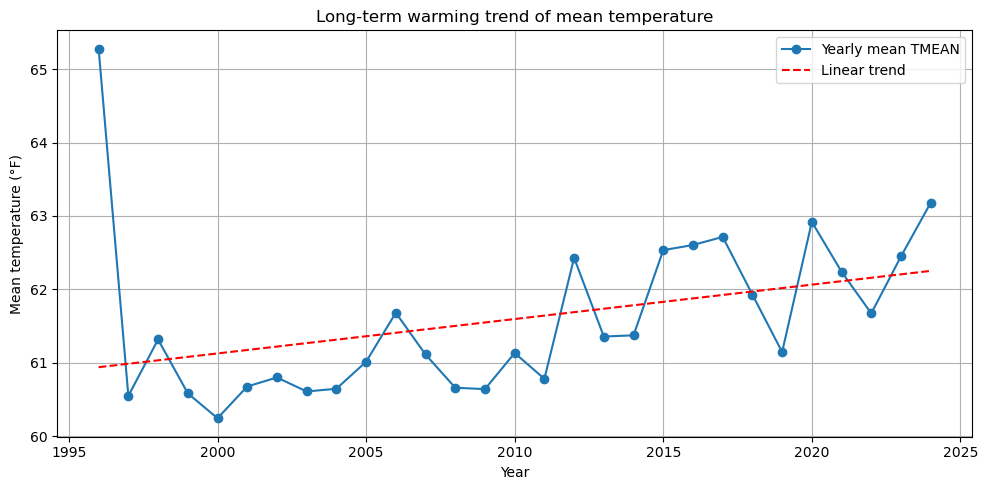

In [22]:
import numpy as np

# Compute station-averaged monthly TMEAN per year
yearly_trend = (
    df.groupby('year')['TMEAN']
    .mean()
    .reset_index()
)

# Fit a linear trend line
z = np.polyfit(yearly_trend['year'], yearly_trend['TMEAN'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))
plt.plot(yearly_trend['year'], yearly_trend['TMEAN'], marker='o', label='Yearly mean TMEAN')
plt.plot(yearly_trend['year'], p(yearly_trend['year']), linestyle='--', color='red', label='Linear trend')

plt.title('Long-term warming trend of mean temperature')
plt.xlabel('Year')
plt.ylabel('Mean temperature (°F)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 12-month Rolling Mean

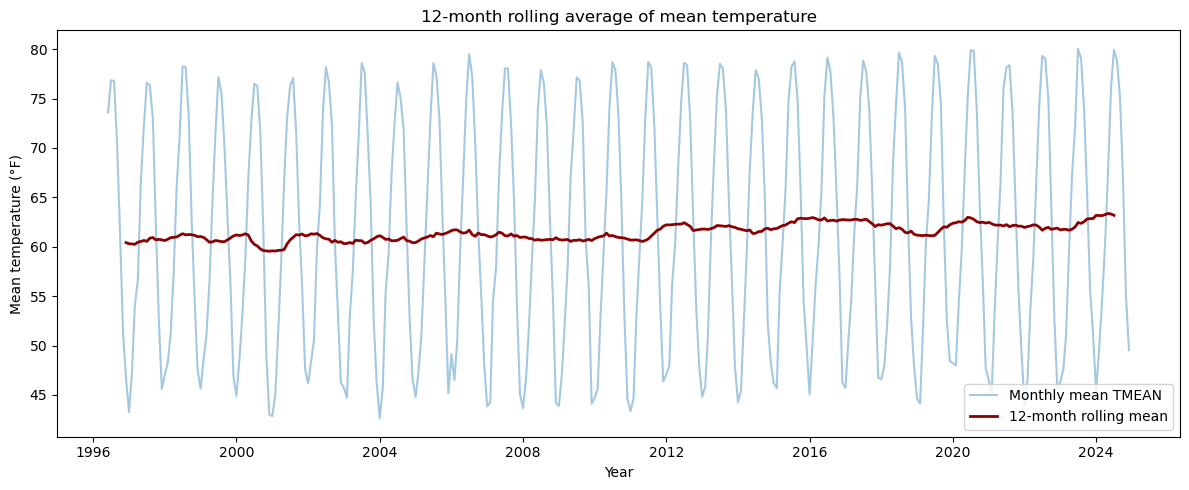

In [23]:
# 12-month rolling average of temperature
ts = (
    df.groupby('ym')['TMEAN']
    .mean()
    .sort_index()
)

rolling_12 = ts.rolling(12, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts.values, alpha=0.4, label='Monthly mean TMEAN')
plt.plot(rolling_12.index, rolling_12.values, color='darkred', linewidth=2, label='12-month rolling mean')

plt.title('12-month rolling average of mean temperature')
plt.xlabel('Year')
plt.ylabel('Mean temperature (°F)')
plt.legend()
plt.tight_layout()
plt.show()

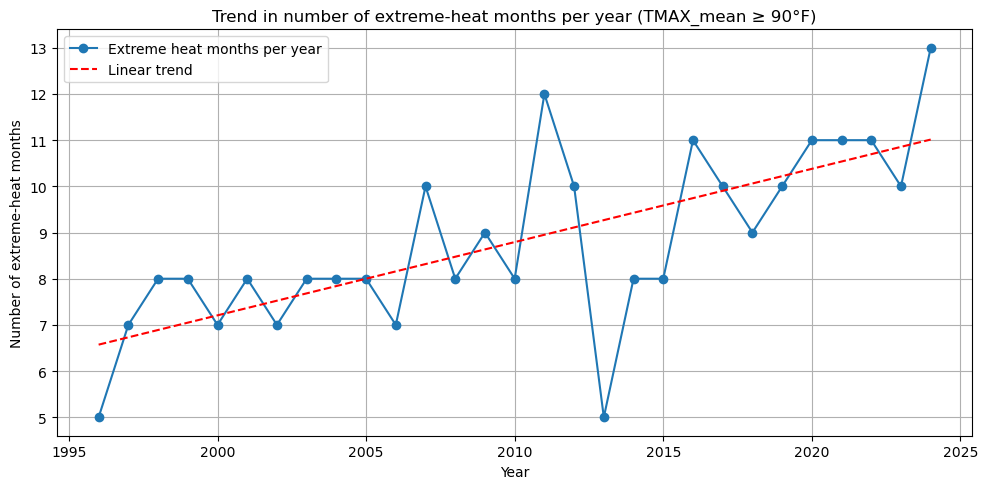

In [29]:
heat_threshold = 90  # Fahrenheit

# Create a column indicating extreme heat months
df['extreme_heat'] = (df['TMAX_mean'] >= heat_threshold).astype(int)

# Count number of extreme-heat months per year
heat_trend = (
    df.groupby('year')['extreme_heat']
    .sum()
    .reset_index()
)

# Fit a simple linear trend
import numpy as np

z = np.polyfit(heat_trend['year'], heat_trend['extreme_heat'], 1)
p = np.poly1d(z)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(heat_trend['year'], heat_trend['extreme_heat'], marker='o', label='Extreme heat months per year')
plt.plot(heat_trend['year'], p(heat_trend['year']), linestyle='--', color='red', label='Linear trend')

plt.title('Trend in number of extreme-heat months per year (TMAX_mean ≥ 90°F)')
plt.xlabel('Year')
plt.ylabel('Number of extreme-heat months')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


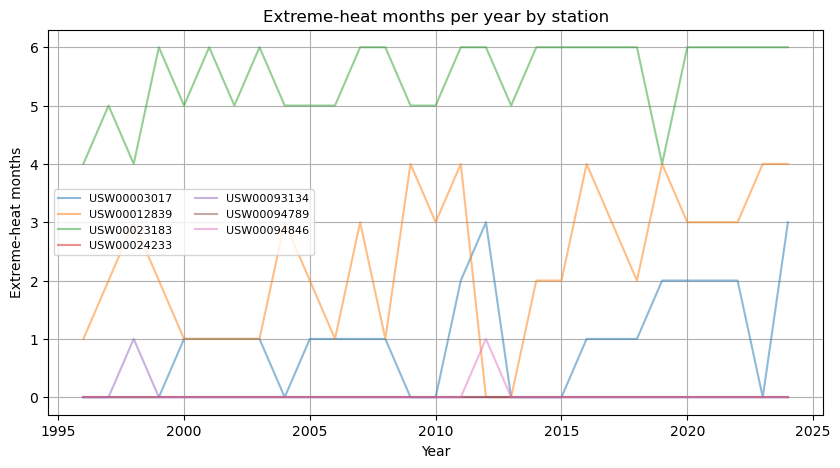

In [30]:
heat_station = df.groupby(['year','STATION'])['extreme_heat'].sum().reset_index()

plt.figure(figsize=(10,5))
for s, sub in heat_station.groupby('STATION'):
    plt.plot(sub['year'], sub['extreme_heat'], alpha=0.5, label=s)

plt.title('Extreme-heat months per year by station')
plt.xlabel('Year')
plt.ylabel('Extreme-heat months')
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.show()


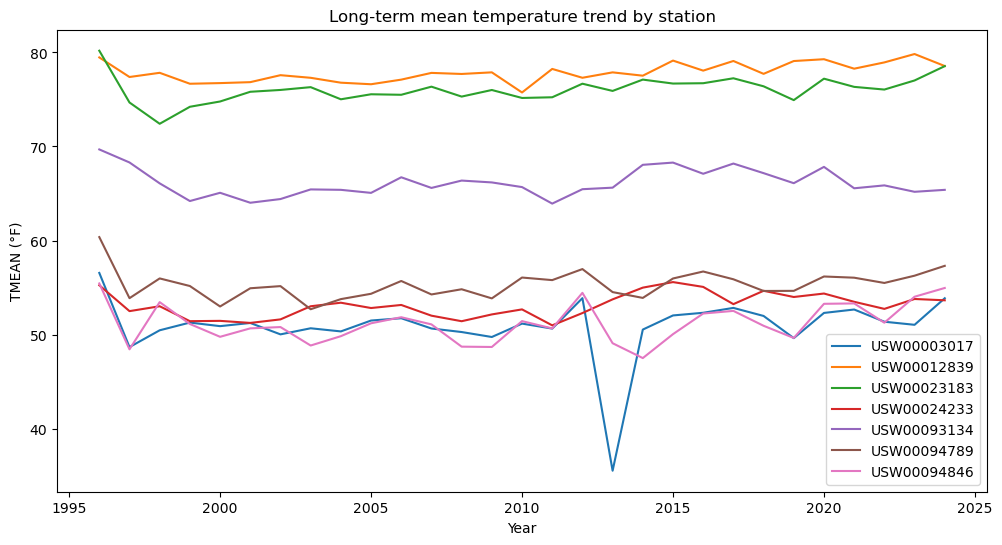

In [31]:
plt.figure(figsize=(12,6))
for st in df['STATION'].unique():
    tmp = df[df['STATION']==st].groupby('year')['TMEAN'].mean()
    plt.plot(tmp.index, tmp.values, label=st)

plt.legend()
plt.title("Long-term mean temperature trend by station")
plt.xlabel("Year")
plt.ylabel("TMEAN (°F)")
plt.show()


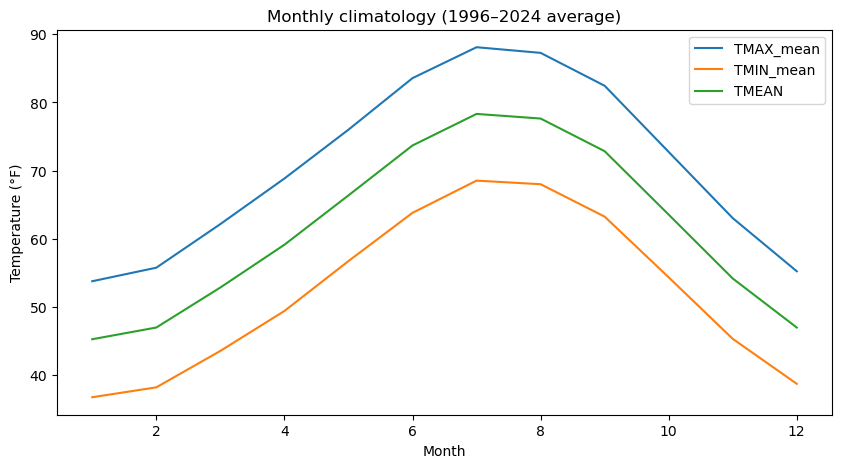

In [32]:
monthly_clim = df.groupby('month')[['TMAX_mean','TMIN_mean','TMEAN']].mean()

monthly_clim.plot(figsize=(10,5))
plt.title("Monthly climatology (1996–2024 average)")
plt.xlabel("Month")
plt.ylabel("Temperature (°F)")
plt.show()


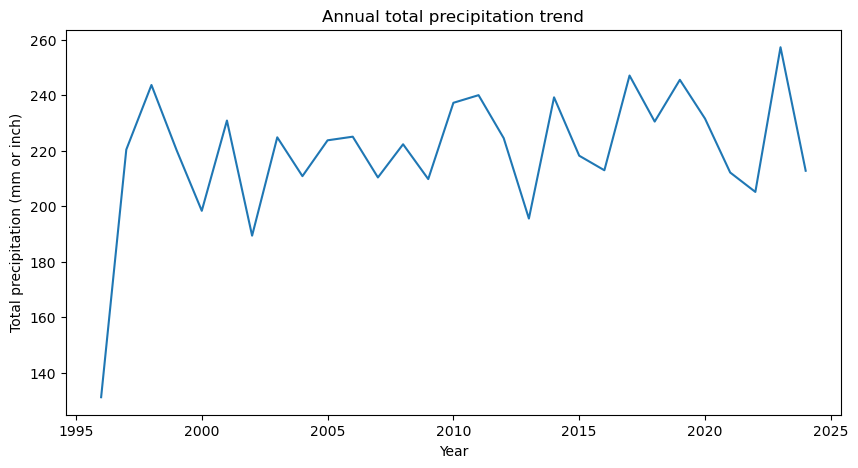

In [33]:
annual_prcp = df.groupby('year')['PRCP_sum'].sum()
annual_prcp.plot(figsize=(10,5))
plt.title("Annual total precipitation trend")
plt.xlabel("Year")
plt.ylabel("Total precipitation (mm or inch)")
plt.show()


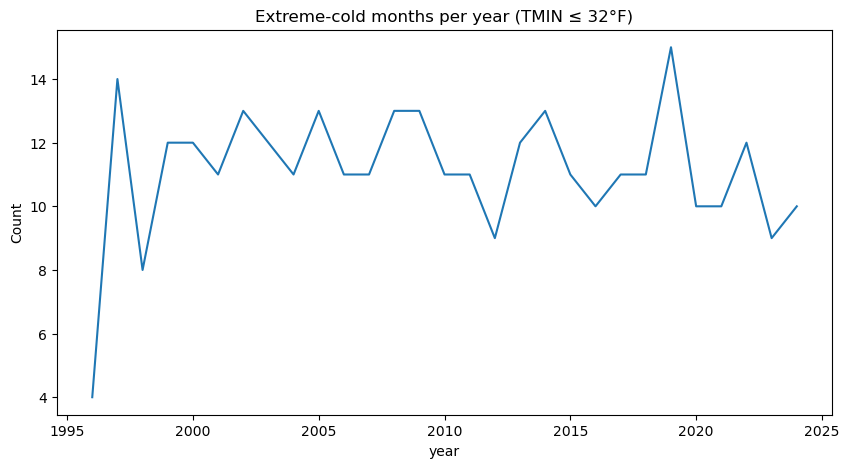

In [34]:
cold = df[df['TMIN_mean'] <= 32]
cold_yearly = cold.groupby('year').size()
cold_yearly.plot(figsize=(10,5))
plt.title("Extreme-cold months per year (TMIN ≤ 32°F)")
plt.ylabel("Count")
plt.show()


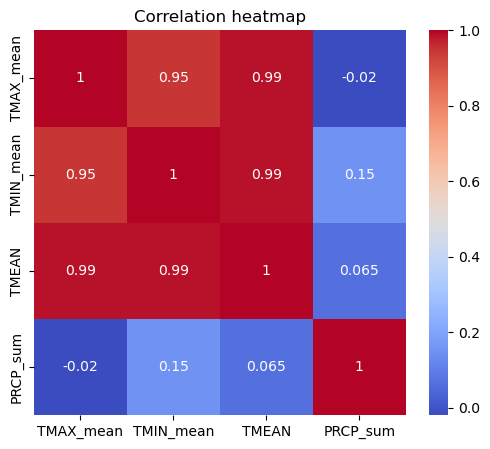

In [35]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(df[['TMAX_mean','TMIN_mean','TMEAN','PRCP_sum']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()
